In [1]:
# Common Libraries
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
import os
import re
import sys
import json
import torch
import argparse
import gc
import time
import glob
import random
import ssl
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict

# Astropy imports
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord, search_around_sky
import astropy.units as u
from astropy.io import fits
from astropy.table import Table, Column
from astropy.nddata import Cutout2D
from astropy.visualization import make_lupton_rgb

# Detectron2 setup
import detectron2.utils.comm as comm
from detectron2.utils.logger import setup_logger
setup_logger()  # Setup Detectron2 logger
from detectron2.config import LazyConfig, get_cfg
from detectron2.engine import launch
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import DatasetCatalog, MetadataCatalog, build_detection_test_loader
from detectron2 import structures
from detectron2.structures import BoxMode, Boxes
import detectron2.data as d2data
import pycocotools.mask as mask_util

# DeepDisc imports
from deepdisc.data_format.image_readers import RomanImageReader
from deepdisc.data_format.register_data import register_data_set
from deepdisc.inference.predictors import return_predictor_transformer, get_predictions
from deepdisc.astrodet.visualizer import Visualizer, ColorMode
import deepdisc.astrodet.astrodet as toolkit  # For COCOEvaluatorRecall


# Matplotlib and other libraries
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
from tqdm import tqdm

# Additional imports
import FoFCatalogMatching

/home/yse2/.conda/envs/deepdisc/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model Config and Setting Parameters

In [21]:
run_dir = './lsst_runs/run14_sm_lvl5'
match = re.search(r'run\d+_(.+)', run_dir)
if match:
    run_name = match.group(1)
    print(run_name)
test_data_file = f'test.json'
with open(test_data_file, 'r') as f:
    test_data = json.load(f)

sm_lvl5


In [23]:
num_channels = 6
means_arr = np.empty((0, num_channels))
stds_arr = np.empty((0, num_channels))
for entry in test_data:
    filename = entry['file_name'][6:]
    if not os.path.exists(filename):
        print(f"Skipping non-existent file: {filename}")
        continue
    if entry['height'] == 0 or entry['width'] == 0:
        print(f"Skipping empty image: {filename}")
        continue
    img_data = np.load(filename)
    means_for_filters = np.mean(img_data, axis=(2, 1))
    means_for_filters = np.reshape(means_for_filters, (1, num_channels))
    stds_for_filters = np.std(img_data, axis=(2, 1))
    stds_for_filters = np.reshape(stds_for_filters, (1, num_channels))

    means_arr = np.concatenate((means_arr, means_for_filters), axis=0)
    stds_arr = np.concatenate((stds_arr, stds_for_filters), axis=0)

pixel_mean = means_arr.mean(axis=0)
pixel_std = stds_arr.mean(axis=0)

print("model.pixel_mean = [")
for value in pixel_mean:
    print(f"    {value},")
print("]")

print("\nmodel.pixel_std = [")
for value in pixel_std:
    print(f"    {value},")
print("]")

model.pixel_mean = [
    2.6730475305428785,
    4.275834970843462,
    6.809507147834191,
    6.69233109673254,
    8.969261629388402,
    12.779275590802701,
]

model.pixel_std = [
    32.052843566092996,
    42.218819296765645,
    70.36132035634017,
    66.37097275099367,
    89.78233172762822,
    145.37383815577897,
]


Now, copy this into `swin_lsst_job.py` replacing the pixel mean and std of the simulated data.

In [ ]:
cfg_file = "swin_lsst_job.py" # replace this with the config file from DeepDISC Roman rubin repo yash branch
# 0.45 0.5 was used for that AstroFest plot comparison of unrecognized blends
topk_per_img = 2000
score_thresh = 0.45 # 0.53
nms_thresh = 0.3
model_path = None
imreader = RomanImageReader()

"""Load model configuration and checkpoint."""
model_path = '../lsst_runs/run14_sm_lvl5/sm_lvl5.pth' # replace this with the checkpoint file that Yash gives
if not model_path:
    raise ValueError(f"No valid checkpoint file found in {run_dir}")


print(f"Using checkpoint file: {model_path}")

# loading config
print(f"\nLoading configs from {cfg_file}...")
cfg = LazyConfig.load(cfg_file)
for key in cfg.get("MISC", dict()).keys():
    cfg[key] = cfg.MISC[key]

# model params
cfg.model.pixel_mean = [
    2.6730475305428785,
    4.275834970843462,
    6.809507147834191,
    6.69233109673254,
    8.969261629388402,
    12.779275590802701,
]

cfg.model.pixel_std = [
    32.052843566092996,
    42.218819296765645,
    70.36132035634017,
    66.37097275099367,
    89.78233172762822,
    145.37383815577897,
]
cfg.train.init_checkpoint = model_path
for box_predictor in cfg.model.roi_heads.box_predictors:
    box_predictor.test_topk_per_image = topk_per_img
    box_predictor.test_score_thresh = score_thresh
    box_predictor.test_nms_thresh = nms_thresh

    
# normalization factor to DP1 data
# # initialize predictor
predictor = return_predictor_transformer(cfg)

# """Load and register test dataset."""
# print(f"\nLoading test data from {test_data_file}...")


# Force re-registration
# Remove the dataset and its metadata first, if they exist.
# This prevents the AssertionError when registering again.
dataset_name = 'test'
print(f"Attempting to remove existing registration for '{dataset_name}'...")
if dataset_name in DatasetCatalog.list():
    DatasetCatalog.remove(dataset_name)
    print(f"Removed '{dataset_name}' from DatasetCatalog.")
# It's important to remove from MetadataCatalog too!
if dataset_name in MetadataCatalog.list():
    MetadataCatalog.remove(dataset_name)
    print(f"Removed '{dataset_name}' from MetadataCatalog.")
try:
    custom_colors = [
        (0, 255, 0),    # green for galaxies
        (0, 0, 255),    # blue for stars
    ]
    print(f"Registering dataset '{dataset_name}'...")
    registered_test_data = register_data_set('test', 
                    test_data_file, 
                    thing_classes=["galaxy", "star"]).set(thing_colors=custom_colors)
except AssertionError:
    print("\nTest dataset already registered")

Using checkpoint file: ../lsst_runs/run14_sm_lvl5/sm_lvl5.pth

Loading configs from ../deepdisc/configs/solo/swin_lsst.py...
[08/14 15:16:22 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ../lsst_runs/run14_sm_lvl5/sm_lvl5.pth ...
Attempting to remove existing registration for 'test'...
Removed 'test' from DatasetCatalog.
Removed 'test' from MetadataCatalog.
Registering dataset 'test'...


In [ ]:
def img_key_mapper(dataset_dict):
    """Maps image keys for data loader."""
    return dataset_dict["file_name"]

pred_ras = []
pred_decs = []
filenames = []
full_outputs = []

# Running DeepDISC on a Single Cutout

In [137]:
from astropy.visualization import AsinhStretch, MinMaxInterval, ImageNormalize
import matplotlib.pyplot as plt
def asinh_norm(data, a=0.1):
    finite_data = data[np.isfinite(data)] # ensure no NaN or inf vals
    if len(finite_data) == 0:
        return ImageNormalize(vmin=0, vmax=1, stretch=AsinhStretch(a=a))
    # percentile-based limits
    vmin, vmax = np.percentile(finite_data, [1, 99])
    return ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(a=a))

In [8]:
viable_cutouts = [entry for entry in test_data if entry['viable']]

In [153]:
# rand_idx = 900
# 15/200/300/700/900 is decent
# filename = viable_cutouts[rand_idx]['file_name']
rand_idx = None
filename = "./dp1/p34/full_c525.npy"
for idx, item in enumerate(viable_cutouts):
    if item['file_name'] == filename:
        print(f"Index: {idx}")
        rand_idx = idx
        break

print(f"Running DeepDISC on {filename}")
match = re.search(r'p(\d+)/full_c(\d+)\.npy', filename)
if match:
    patch_id = int(match.group(1))
    cutout_num = int(match.group(2))
    print(f"Patch ID: {patch_id}, Cutout #: {cutout_num}")
else:
    print("Filename format not recognized.")

Index: 1050
Running DeepDISC on ./dp1/p34/full_c525.npy
Patch ID: 34, Cutout #: 525


In [154]:
random_cutout = np.load(filename[6:])
# print(random_cutout.shape)

# vis_img = random_cutout[3, :, :]
r = random_cutout[3, :, :] # i
g = random_cutout[2, :, :] # r
b = random_cutout[1, :, :] # g
pmin = np.percentile([r, g, b], 1)
pmax = np.percentile([r, g, b], 99.5)
# stretch (float): controls linear stretch. Higher vals increase contrast, which can help reveal fainter details
stretch = pmax - pmin # ~27.160368
# print(stretch)
# Q (int): adjusts the Asinh softening. Helps control scaling of image's dynamic range.
vis_img = make_lupton_rgb(r, g, b, minimum=pmin, stretch=stretch, Q=10)
v0 = Visualizer(
    vis_img,
    metadata=registered_test_data,
    scale=5,
    instance_mode=ColorMode.SEGMENTATION,
    enable_color_jitter=False# remove the colors of unsegmented pixels. This option is only available for segmentation models
)
# outputs = predictor(random_cutout)
outputs = get_predictions(viable_cutouts[rand_idx], imreader, img_key_mapper, predictor)
out = v0.draw_instance_predictions(outputs["instances"].to("cpu"), alpha=0, lf=False)
# prediction_output_lsst = v_lsst.draw_instance_predictions(outputs_lsst["instances"].to("cpu"), alpha=0, lf=False)

print("detected instances:", len(outputs["instances"].pred_boxes))
print("")

Setting colors
detected instances: 37



Text(0.5, 1.0, 'Predictions')

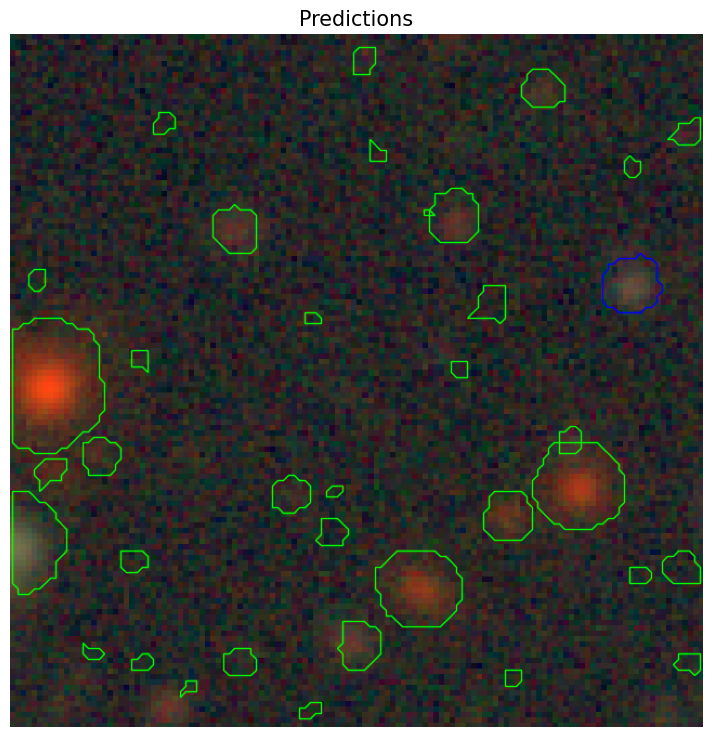

In [155]:
fig, ax1 = plt.subplots(1, 1, figsize=(9, 9))
ax1.imshow(vis_img, origin='lower')
ax1.imshow(out.get_image(), origin='lower')
ax1.axis("off")
ax1.set_title('Predictions',fontsize=15)
# plt.imshow(random_cutout[3, :, :], norm=asinh_norm(random_cutout[3, :, :], a=0.1), origin='lower', cmap='viridis')

In [82]:
space_cat = pd.read_json('hst_dets_lsst.json', orient='records') 
print(f"We loaded in {len(space_cat)} objects.")
space_cat = space_cat[np.isfinite(space_cat['mag_F814W'])].copy()
# there's some mags that are 37 so wet set 30 as the upper limit
space_cat = space_cat[space_cat['mag_F814W'] <= 30].copy()
print(f"After first mag cuts: we have {len(space_cat)} objects")
space_cat.reset_index(drop=True, inplace=True) # drop=True prevents pandas from creating a new 'index' column

We loaded in 34612 objects.
After first mag cuts: we have 32656 objects


In [156]:
patch_cutout = f'p{patch_id}/full_c{cutout_num}.npy'
lsst_iband_img = np.load(patch_cutout)[3,:, :]
patch_cat = f'full_p{patch_id}.json'
catalog_df = pd.read_json(patch_cat, orient='records')

target_filename = f'./dp1/p{patch_id}/full_c{cutout_num}.npy'
cutout_info = None
for cutout in test_data:
    if cutout['file_name'] == target_filename:
        cutout_info = cutout
        break

if cutout_info is None:
    print(f"Could not find cutout info for {target_filename}")

cutout_wcs = WCS(cutout_info['wcs'])
# print(cutout_wcs)
height, width = lsst_iband_img.shape
corners_pix = np.array([
    [0, 0],           # bottom-left
    [width-1, 0],     # bottom-right  
    [width-1, height-1], # top-right
    [0, height-1]     # top-left
])
# print(height, width)
corners_world = cutout_wcs.pixel_to_world(corners_pix[:, 0], corners_pix[:, 1])
corner_ras = corners_world.ra.degree
corner_decs = corners_world.dec.degree

print(f"Cutout corners (RA, Dec):")
for i, (ra, dec) in enumerate(zip(corner_ras, corner_decs)):
    print(f"  Corner {i}: RA={ra:.6f}, Dec={dec:.6f}")
    
ra_min, ra_max = corner_ras.min(), corner_ras.max()
dec_min, dec_max = corner_decs.min(), corner_decs.max()

print(f"Loaded catalog with {len(catalog_df)} objects")
within_bounds = (
    (catalog_df['coord_ra'] >= ra_min) & (catalog_df['coord_ra'] <= ra_max) &
    (catalog_df['coord_dec'] >= dec_min) & (catalog_df['coord_dec'] <= dec_max)
)
within_bounds_space = (
    (space_cat['RA'] >= ra_min) & (space_cat['RA'] <= ra_max) &
    (space_cat['DEC'] >= dec_min) & (space_cat['DEC'] <= dec_max)
)

catalog_in_cutout = catalog_df[within_bounds]
space_cat_in_cutout = space_cat[within_bounds_space]

print(f"Found {len(catalog_in_cutout)} catalog objects within cutout bounds")
print(f"Found {len(space_cat_in_cutout)} space catalog objects within cutout bounds")

cat_coords = SkyCoord(ra=catalog_in_cutout['coord_ra'].values*u.deg, dec=catalog_in_cutout['coord_dec'].values*u.deg)
cat_world = cutout_wcs.world_to_pixel(cat_coords)

space_cat_coords = SkyCoord(ra=space_cat_in_cutout['RA'].values*u.deg, dec=space_cat_in_cutout['DEC'].values*u.deg)
space_cat_world = cutout_wcs.world_to_pixel(space_cat_coords)

# plt.figure(figsize=(9,9))
# plt.scatter(cat_world[0], cat_world[1], marker='x', label='LSST Detections', c=['red'])
# plt.imshow(lsst_iband_img, norm=asinh_norm(lsst_iband_img, a=0.1), origin='lower', cmap='viridis')

Cutout corners (RA, Dec):
  Corner 0: RA=53.120749, Dec=-27.695046
  Corner 1: RA=53.112781, Dec=-27.695047
  Corner 2: RA=53.112779, Dec=-27.687992
  Corner 3: RA=53.120747, Dec=-27.687990
Loaded catalog with 11063 objects
Found 21 catalog objects within cutout bounds
Found 40 space catalog objects within cutout bounds


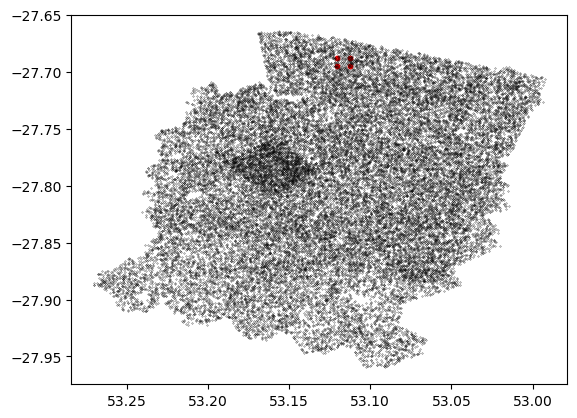

In [157]:
plt.scatter(corner_ras, corner_decs, s=10, c=['red'], label='Corners')
plt.scatter(space_cat['RA'], space_cat['DEC'], s=0.05, label='HST Detections', c=['black'])
plt.gca().invert_xaxis()

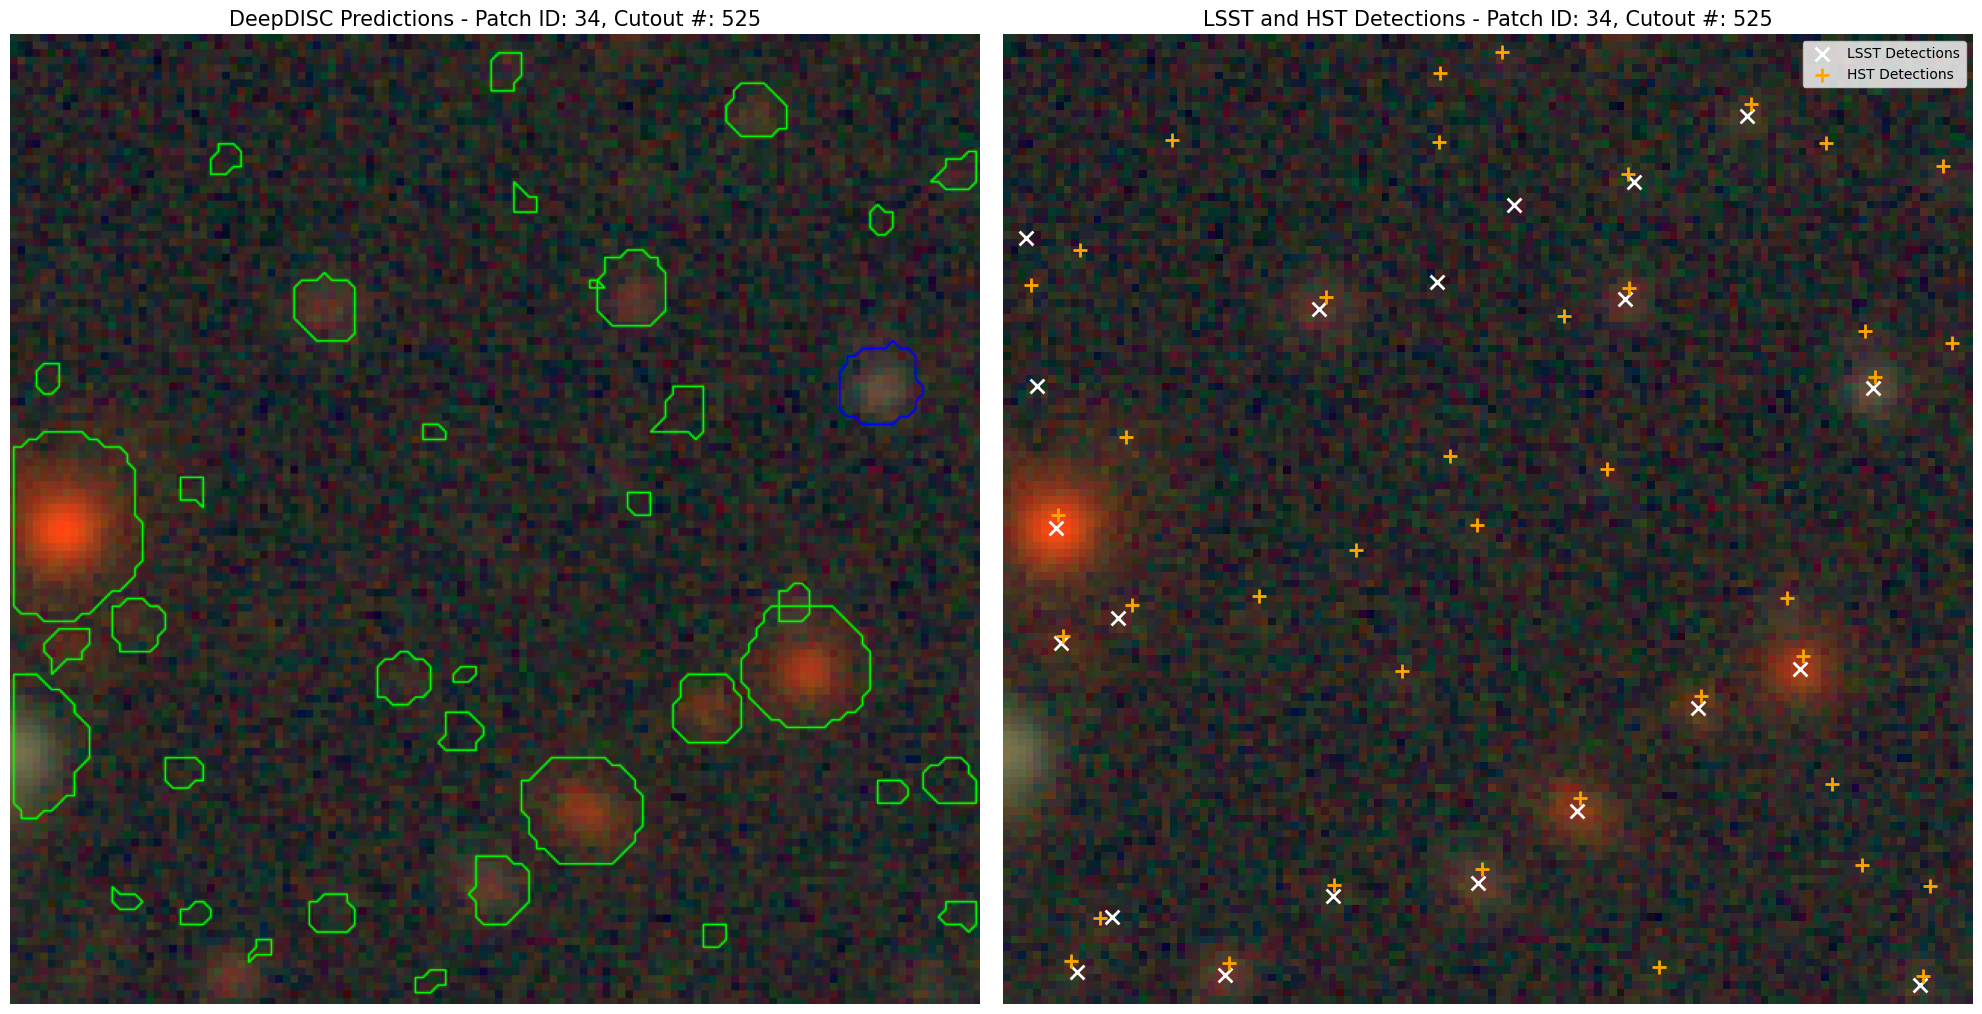

In [158]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left panel: Predictions only
axes[0].imshow(out.get_image(), origin='lower')
axes[0].axis('off')
axes[0].set_title(f'DeepDISC Predictions - Patch ID: {patch_id}, Cutout #: {cutout_num}', fontsize=15)

# axes[1].imshow(out.get_image(), origin='lower')
axes[1].imshow(vis_img, origin='lower')
axes[1].scatter(cat_world[0], cat_world[1], marker='x', s=100, 
                color='white', label='LSST Detections', linewidth=2)
axes[1].scatter(space_cat_world[0], space_cat_world[1], marker='+', s=100, 
                color='orange', label='HST Detections', linewidth=2)
axes[1].axis('off')
axes[1].set_title(f'LSST and HST Detections - Patch ID: {patch_id}, Cutout #: {cutout_num}', fontsize=15)
axes[1].legend() 

plt.tight_layout()

# Running DeepDISC on All Overlapping Cutouts

In [44]:
for d in tqdm(test_data, desc="Getting predictions"):
    if d['viable']:
    #     imid = d['image_id']
        filename = d['file_name']
    #     patch = d['patch']
        wcs = WCS(d['wcs'])
        height, width = d['height'], d['width']

        outputs = get_predictions(d, imreader, img_key_mapper, predictor)
        raw_instances = outputs['instances']
        centers_pred = raw_instances.pred_boxes.get_centers().cpu().numpy()
        pred_coords = wcs.pixel_to_world(centers_pred[:,0],centers_pred[:,1])
        # extend all lists with prediction info
        n_preds = len(centers_pred)
        pred_ras.extend(pred_coords.ra.degree)
        pred_decs.extend(pred_coords.dec.degree)
        filenames.extend([filename] * n_preds)

        for i in range(len(raw_instances)):
            instance = raw_instances[i]
            serializable_instance_data = {
                'file_name': filename,
                'wcs': d['wcs'],
                'pred_id': i,
            }
            if instance.has('pred_boxes'):
                serializable_instance_data['pred_boxes'] = instance.pred_boxes.tensor.cpu().numpy().tolist()
            if instance.has('scores'):
                serializable_instance_data['scores'] = instance.scores.cpu().numpy().tolist()
            if instance.has('pred_classes'):
                serializable_instance_data['pred_classes'] = instance.pred_classes.cpu().numpy().tolist()        
            # binary mask to RLE format
            if instance.has('pred_masks'):
                mask_array = instance.pred_masks[0].cpu().numpy() # single (H, W) mask since shape is (1, H, W) of True/False
                # pycocotools expects a Fortran-contiguous array of type uint8
                fortran_mask = np.asfortranarray(mask_array.astype(np.uint8))
                # encode the mask into RLE format
                rle = mask_util.encode(fortran_mask)
                # 'counts' field is in bytes, which is not JSON serializable, so let's decode it to a string
                rle['counts'] = rle['counts'].decode('utf-8')
                serializable_instance_data['segmentation_rle'] = rle
            full_outputs.append(serializable_instance_data)

dd_det_cat = {
    'ra': np.array(pred_ras),
    'dec': np.array(pred_decs),
    'file_name': np.array(filenames)
}

Getting predictions: 100%|██████████| 3174/3174 [03:58<00:00, 13.30it/s] 


In [45]:
full_pred_output_file = f'full_pred_output_s{score_thresh}_n{nms_thresh}.json'
with open(full_pred_output_file, 'w') as f:
    json.dump(full_outputs, f, indent=4)
print(f"Saved full prediction outputs (from Instances) to {full_pred_output_file}")

Saved full prediction outputs (from Instances) to full_pred_output_s0.45_n0.3.json


In [46]:
predictions_file = f'pred_s{score_thresh}_n{nms_thresh}.json'
pd.DataFrame(dd_det_cat).to_json(predictions_file, orient='records')
print(f"Saved to {predictions_file}!")

Saved to pred_s0.45_n0.3.json!


In [47]:
dd_det_cat_df = pd.DataFrame(dd_det_cat)
dd_det_cat_df

,ra,dec,file_name
0,53.274208,-27.961126,./dp1/p24/full_c184.npy
1,53.275083,-27.960102,./dp1/p24/full_c184.npy
2,53.272620,-27.957812,./dp1/p24/full_c184.npy
3,53.270057,-27.960406,./dp1/p24/full_c184.npy
4,53.275025,-27.956074,./dp1/p24/full_c184.npy
...,...,...,...
28019,52.991646,-27.663455,./dp1/p45/full_c80.npy
28020,52.996345,-27.661827,./dp1/p45/full_c80.npy
28021,52.993213,-27.664605,./dp1/p45/full_c80.npy
28022,52.990038,-27.660929,./dp1/p45/full_c80.npy


In [152]:
dd_det_cat_df['file_name'].value_counts()[20:40]

./dp1/p34/full_c518.npy    39
./dp1/p44/full_c68.npy     39
./dp1/p35/full_c466.npy    38
./dp1/p44/full_c56.npy     38
./dp1/p34/full_c477.npy    38
./dp1/p44/full_c32.npy     38
./dp1/p45/full_c78.npy     38
./dp1/p44/full_c3.npy      37
./dp1/p44/full_c69.npy     37
./dp1/p44/full_c70.npy     37
./dp1/p44/full_c1.npy      37
./dp1/p44/full_c47.npy     37
./dp1/p44/full_c20.npy     37
./dp1/p44/full_c21.npy     37
./dp1/p45/full_c80.npy     37
./dp1/p44/full_c25.npy     37
./dp1/p45/full_c76.npy     37
./dp1/p45/full_c56.npy     37
./dp1/p45/full_c53.npy     37
./dp1/p34/full_c525.npy    37
Name: file_name, dtype: int64

# Adding Magnitudes to Predictions

In [21]:
full_pred_output_file = f'full_pred_output_s{score_thresh}_n{nms_thresh}.json'
predictions_file = f'pred_s{score_thresh}_n{nms_thresh}.json'

print("Loading existing prediction files...")
with open(full_pred_output_file, 'r') as f:
    full_outputs = json.load(f)

dd_det_cat_df = pd.read_json(predictions_file, orient='records')
read_in = True

Loading existing prediction files...


In [48]:
read_in = False

In [49]:
def reconstruct_mask_from_rle(rle_dict, read_in_json=False):
    """
    Reconstructs a binary mask from a COCO RLE dictionary.
    """
    # 'counts' field saved as a string, so we encode it back to bytes
    if read_in_json:
        rle_dict['counts'] = rle_dict['counts'].encode('utf-8')
    # decode RLE to a binary mask
    mask = mask_util.decode(rle_dict)
    return mask.astype(bool)

def calculate_mags_all_bands(filename, rle_data, read_in_json=False):
    """
    Calculate predicted mags from segmentation mask and image data for all 6 bands.
    
    Args:
        filename: Path to the .npy image file
        rle_data: RLE segmentation data
    
    Returns:
        Dictionary with mags for all bands: {band_name: mag}
    """
    reconstructed_mask = reconstruct_mask_from_rle(rle_data, read_in_json)
    lsst_image = np.load(filename[6:])
    
    band_names = ['u', 'g', 'r', 'i', 'z', 'y']
    mags = {}
    
    for band_idx, band_name in enumerate(band_names):
        band_image = lsst_image[band_idx]
        instrumental_flux = np.sum(band_image[reconstructed_mask])
        
        # edge case where flux might be zero or negative
        if instrumental_flux <= 0:
            mags[f'mag_{band_name}'] = np.nan
        else:
            mag = 31.4 - 2.5 * np.log10(instrumental_flux) # double check zeropoint
            mags[f'mag_{band_name}'] = mag
    
    return mags

print(f"Processing {len(dd_det_cat_df)} predictions to calculate mags for all 6 bands...")

band_names = ['u', 'g', 'r', 'i', 'z', 'y']
pred_mags = {f'mag_{band}': [] for band in band_names}

for i, pred in enumerate(full_outputs):
    if i % 10000 == 0:  # Progress indicator
        print(f"Processing prediction {i}/{len(full_outputs)}")
    
    filename = pred['file_name']
    
    if 'segmentation_rle' in pred:
        rle_data = pred['segmentation_rle']
        mags = calculate_mags_all_bands(filename, rle_data, read_in_json=read_in)
        
        for band_name in band_names:
            pred_mags[f'mag_{band_name}'].append(mags[f'mag_{band_name}'])
    else:
        # If no seg mask, NaN for all bands
        for band_name in band_names:
            pred_mags[f'mag_{band_name}'].append(np.nan)

print("Adding mags for all bands to prediction data...")

# adding to dd_det_cat now
for band_name in band_names:
    dd_det_cat_df[f'mag_{band_name}'] = pred_mags[f'mag_{band_name}']

# add mags to the full outputs
for i, prediction in enumerate(full_outputs):
    for band_name in band_names:
        full_outputs[i][f'mag_{band_name}'] = pred_mags[f'mag_{band_name}'][i]

Processing 28024 predictions to calculate mags for all 6 bands...
Processing prediction 0/28024
Processing prediction 10000/28024
Processing prediction 20000/28024
Adding mags for all bands to prediction data...


In [50]:
# 31.4 from print(exp.getPhotoCalib().instFluxToMagnitude(1.0)) # 31.4
updated_full_pred_file = f'full_pred_output_s{score_thresh}_n{nms_thresh}.json'
with open(updated_full_pred_file, 'w') as f:
    json.dump(full_outputs, f, indent=4)
print(f"Saved updated full prediction outputs to {updated_full_pred_file}")

updated_predictions_file = f'pred_s{score_thresh}_n{nms_thresh}.json'
dd_det_cat_df.to_json(updated_predictions_file, orient='records')
print(f"Saved updated predictions with mags to {updated_predictions_file}")
print(f"\nmag statistics for all bands:")
print(f"Total predictions: {len(dd_det_cat_df)}")

for band_name in band_names:
    col_name = f'mag_{band_name}'
    valid_mags = dd_det_cat_df[col_name].dropna()
    print(f"\n{band_name.upper()}-band:")
    print(f"  Valid mags: {len(valid_mags)}")
    if len(valid_mags) > 0:
        print(f"  Mean mag: {valid_mags.mean():.2f}")
        print(f"  Median mag: {valid_mags.median():.2f}")
        print(f"  Min mag: {valid_mags.min():.2f}")
        print(f"  Max mag: {valid_mags.max():.2f}")
    else:
        print(f"  No valid mags found")

Saved updated full prediction outputs to full_pred_output_s0.45_n0.3.json
Saved updated predictions with mags to pred_s0.45_n0.3.json

mag statistics for all bands:
Total predictions: 28024

U-band:
  Valid mags: 24207
  Mean mag: 26.35
  Median mag: 26.41
  Min mag: 14.34
  Max mag: 38.62

G-band:
  Valid mags: 25711
  Mean mag: 26.66
  Median mag: 26.61
  Min mag: 13.45
  Max mag: 40.29

R-band:
  Valid mags: 25664
  Mean mag: 26.19
  Median mag: 26.17
  Min mag: 13.07
  Max mag: 37.13

I-band:
  Valid mags: 25876
  Mean mag: 25.79
  Median mag: 25.83
  Min mag: 14.69
  Max mag: 37.65

Z-band:
  Valid mags: 24740
  Mean mag: 25.47
  Median mag: 25.58
  Min mag: 14.40
  Max mag: 36.50

Y-band:
  Valid mags: 23607
  Mean mag: 24.65
  Median mag: 24.83
  Min mag: 13.27
  Max mag: 35.62


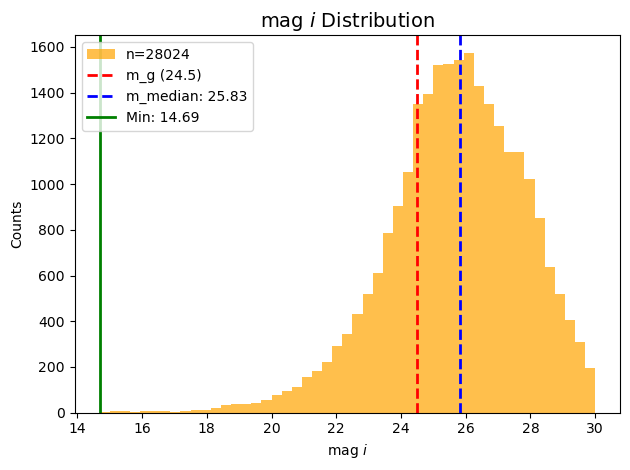

In [54]:
# 31.4 zeropoint
bins = np.linspace(dd_det_cat_df['mag_i'].min(), 30, 50)
# fig, axs = plt.subplots(2, 1, figsize=(8, 12))
plt.title('mag $i$ Distribution', fontsize=14)
plt.hist(dd_det_cat_df[dd_det_cat_df['mag_i'] <= 30]['mag_i'], bins=bins, color='orange', alpha=0.7, 
           label=f'n={len(dd_det_cat_df)}')
plt.axvline(24.5, color='red', linestyle='--', linewidth=2, label='m_g (24.5)')
median_mag = np.median(dd_det_cat_df['mag_i'].dropna())
plt.axvline(median_mag, color='blue', linestyle='--', linewidth=2, label=f'm_median: {median_mag:.2f}')
plt.axvline(dd_det_cat_df['mag_i'].min(), color='green', linestyle='-', 
              linewidth=2, label=f'Min: {dd_det_cat_df["mag_i"].min():.2f}')
# plt.axvline(dd_det_cat_df['mag_i'].max(), color='black', linestyle='-', 
#               linewidth=2, label=f'Max: {dd_det_cat_df["mag_i"].max():.2f}')
plt.xlabel('mag $i$')
plt.ylabel('Counts')
plt.legend(frameon=True)
plt.tight_layout()

# Unrecognized Blend Plot from Tech Note

In [55]:
ground_cat = pd.read_json('pred_s0.45_n0.3.json', orient='records')
print(f"We loaded in {len(ground_cat)} objects.")
# detect_isPrimary (primary objs don't have children - either isolated or deblended children)
# print(f"After detect_isPrimary cut: we have {len(ground_cat)} objects")

We loaded in 28024 objects.


In [56]:
space_cat = pd.read_json('hst_dets_lsst.json', orient='records') 
print(f"We loaded in {len(space_cat)} objects.")
space_cat = space_cat[np.isfinite(space_cat['mag_F814W'])].copy()
# there's some mags that are 37 so wet set 30 as the upper limit
space_cat = space_cat[space_cat['mag_F814W'] <= 30].copy()
print(f"After first mag cuts: we have {len(space_cat)} objects")
space_cat.reset_index(drop=True, inplace=True) # drop=True prevents pandas from creating a new 'index' column

We loaded in 34612 objects.
After first mag cuts: we have 32656 objects


In [57]:
print(f"Final catalog sizes - Ground: {len(ground_cat)}, Space: {len(space_cat)}")

Final catalog sizes - Ground: 28024, Space: 32656


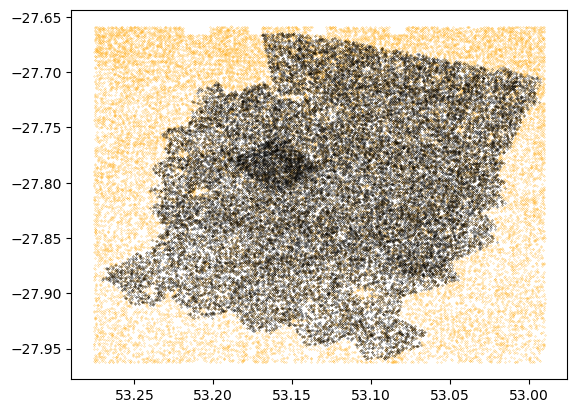

In [58]:
plt.scatter(ground_cat['ra'], ground_cat['dec'], s=0.03, c=['orange'], label='DP1 DeepDISC Detections')
plt.scatter(space_cat['RA'], space_cat['DEC'], s=0.05, label='HST Detections', c=['black'])
plt.gca().invert_xaxis()

In [59]:
def find_unrec_spatial_twostage_full(
    ground_cat, space_cat,
    search_radius=2.0,   # arcsec
    m_s=26.5,            # space completeness limit
    m_delta=2.0,         # mag window around brightest space match
    ms_strict=True       # True -> mag_F814W < m_s; False -> <=
):
    """
    Implements the tech note's 'Stage A' candidate counting and 'Stage C' mag refinement
    for spatial matching only. Returns per-object counts before and after m_delta, as well as
    masks for unrecognized, recognized, pure, spurious, and eligibility.

    Returns:
        is_unrecognized: final classification after m_delta (bool)
        is_recognized: recognized blends based on Stage A (N_s_hat == N_g > 1) (bool)
        is_pure: pure objects based on Stage A (N_s_hat == N_g == 1) (bool)
        is_spurious: Stage A spurious/missing-space (N_g > N_s_hat) (bool)
        eligible_mask: objects used for fractions per the note (N_s_hat >= N_g) (bool)
        has_space_match_ms: N_s_hat > 0 (bool)
        N_g: ground counts within radius including self (int array)
        N_s_hat: space counts after m_s cut (Stage A) (int array)
        N_s_final: space counts after m_delta applied to Stage A space matches (int array)
    """
    # Sky coords
    gcoord = SkyCoord(ground_cat['ra'].values*u.deg,
                      ground_cat['dec'].values*u.deg)
    scoord = SkyCoord(space_cat['RA'].values*u.deg,
                      space_cat['DEC'].values*u.deg)
    
    # Ground-ground within r (Stage A: define N_g)
    gi1, gi2, _, _ = search_around_sky(gcoord, gcoord, search_radius*u.arcsec)
    # Count neighbors per ground object (includes self exactly once)
    N_g = np.bincount(gi1, minlength=len(ground_cat)).astype(int)

    # Ground-space within r (Stage A: define N_s_hat)
    gs_g, gs_s, _, _ = search_around_sky(gcoord, scoord, search_radius*u.arcsec)
    s_mag = space_cat['mag_F814W'].values

    if ms_strict:
        pass_ms = s_mag[gs_s] < m_s
    else:
        pass_ms = s_mag[gs_s] <= m_s

    N_s_hat = np.bincount(gs_g, weights=pass_ms.astype(int), minlength=len(ground_cat)).astype(int)
    has_space_match_ms = N_s_hat > 0

    # Stage A classification (before m_delta)
    # - spurious/missing space: N_g > N_s_hat  (ignored for subsequent analysis)
    # - pure:                    N_g = N_s_hat = 1
    # - recognized:              N_g = N_s_hat > 1
    # - candidate unrecognized:  N_s_hat > N_g  (go to Stage C)
    is_spurious = N_g > N_s_hat
    is_pure = (N_g == 1) & (N_s_hat == 1)
    is_recognized = (N_g > 1) & (N_s_hat == N_g)
    candidates = N_s_hat > N_g

    # Stage C: apply m_delta only to the candidate set
    # Build per-ground list of space matches that pass m_s
    pairs_by_g = {}
    for g_idx, s_idx, ok in zip(gs_g, gs_s, pass_ms):
        if not ok:
            continue
        if g_idx not in pairs_by_g:
            pairs_by_g[g_idx] = []
        pairs_by_g[g_idx].append(s_idx)

    # Final counts after m_delta for every ground object
    N_s_final = np.zeros(len(ground_cat), dtype=int)
    is_unrecognized = np.zeros(len(ground_cat), dtype=bool)

    # For all objects that have any space match after m_s, compute N_s_final
    # - For non-candidates, N_s_final is still computed (useful for diagnostics),
    #   but only candidates can flip to unrecognized after m_delta.
    for g in np.where(has_space_match_ms)[0]:
        s_indices = pairs_by_g.get(g, [])
        if len(s_indices) == 0:
            N_s_final[g] = 0
            continue
        mags = s_mag[s_indices]
        m_bright = np.min(mags)
        keep = mags <= (m_bright + m_delta)  # strictness here is not critical; using <= matches the text’s intent
        N_s = int(np.sum(keep))
        N_s_final[g] = N_s
        if candidates[g] and (N_s > N_g[g]):
            is_unrecognized[g] = True

    # Eligible for fractions per the note = not spurious at Stage A
    eligible_mask = ~is_spurious

    return (is_unrecognized, is_recognized, is_pure, is_spurious,
            eligible_mask, has_space_match_ms, N_g, N_s_hat, N_s_final)

print("\nIdentifying unrecognized blends using two-stage spatial matching (full bookkeeping)...")
(
    is_unrecognized_blend,
    is_recognized_blend,
    is_pure,
    is_spurious,
    eligible_mask,
    has_space_match_ms,
    n_ground,       # N_g
    n_space_hat,    # N_s_hat (after m_s)
    n_space_final   # N_s_final (after m_delta)
) = find_unrec_spatial_twostage_full(
    ground_cat,
    space_cat,
    search_radius=2.0,
    m_s=26.5,
    m_delta=2.0,
    ms_strict=True
)

print(f"Objects with at least one space match after m_s: {np.sum(has_space_match_ms)}/{len(ground_cat)}")
print(f"Eligible for analysis (N_s_hat >= N_g): {np.sum(eligible_mask)}")
print(f"Found unrecognized blends (final): {np.sum(is_unrecognized_blend)}")
print(f"Found recognized blends (Stage A): {np.sum(is_recognized_blend)}")
print(f"Found pure (Stage A): {np.sum(is_pure)}")
print(f"Spurious / missing space (ignored): {np.sum(is_spurious)}")


Identifying unrecognized blends using two-stage spatial matching (full bookkeeping)...
Objects with at least one space match after m_s: 11658/28024
Eligible for analysis (N_s_hat >= N_g): 10230
Found unrecognized blends (final): 1414
Found recognized blends (Stage A): 807
Found pure (Stage A): 7608
Spurious / missing space (ignored): 17794


Mag 18.0 [17.75, 18.25]:   0/   9 = 0.000 ± 0.000
Mag 18.5 [18.25, 18.75]:   0/  14 = 0.000 ± 0.000
Mag 19.0 [18.75, 19.25]:   0/  15 = 0.000 ± 0.000
Mag 19.5 [19.25, 19.75]:   1/  25 = 0.040 ± 0.039
Mag 20.0 [19.75, 20.25]:   1/  40 = 0.025 ± 0.025
Mag 20.5 [20.25, 20.75]:   1/  66 = 0.015 ± 0.015
Mag 21.0 [20.75, 21.25]:   3/ 102 = 0.029 ± 0.017
Mag 21.5 [21.25, 21.75]:  14/ 160 = 0.087 ± 0.022
Mag 22.0 [21.75, 22.25]:  19/ 239 = 0.079 ± 0.017
Mag 22.5 [22.25, 22.75]:  28/ 315 = 0.089 ± 0.016
Mag 23.0 [22.75, 23.25]:  42/ 403 = 0.104 ± 0.015
Mag 23.5 [23.25, 23.75]:  76/ 620 = 0.123 ± 0.013
Mag 24.0 [23.75, 24.25]: 126/ 793 = 0.159 ± 0.013
Mag 24.5 [24.25, 24.75]: 227/1142 = 0.199 ± 0.012

=== Summary ===
Total eligible (N_s_hat >= N_g): 10230
Total unrecognized blends (final): 1414
Overall blend fraction (among eligible): 0.138

We find that for 23 < i <= 24.5, 15.3% of objects are unrecognized blends (eligible denominator).

=== Diagnostic Info (using final N_s) ===
Pure/isolated (

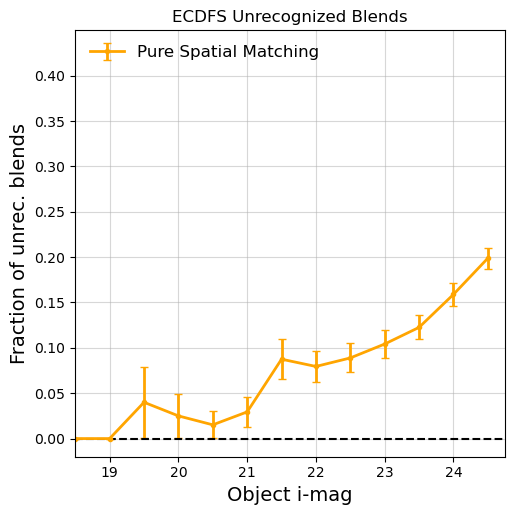

In [60]:
def blend_fraction_by_mag(
    ground_cat,
    is_unrec,            # final unrec mask after m_delta
    eligible_mask,       # per note: ~spurious (N_s_hat >= N_g)
    mag_points,
    bin_width=0.5
):
    fracs, errs, pts, counts = [], [], [], []
    mag = ground_cat['mag_i'].values

    for c in mag_points:
        lo, hi = c - bin_width/2, c + bin_width/2
        in_bin = (mag >= lo) & (mag < hi)

        denom_mask = in_bin & eligible_mask
        n_denom = int(np.sum(denom_mask))
        if n_denom == 0:
            continue

        numer = int(np.sum(in_bin & is_unrec))
        frac = numer / n_denom
        err = np.sqrt(frac*(1-frac)/n_denom) if n_denom > 0 else 0.0

        fracs.append(frac)
        errs.append(err)
        pts.append(c)
        counts.append((numer, n_denom))
        print(f"Mag {c:.1f} [{lo:.2f}, {hi:.2f}]: {numer:3d}/{n_denom:4d} = {frac:.3f} ± {err:.3f}")

    return np.array(pts), np.array(fracs), np.array(errs), counts

# Fractions per the tech note (denominator excludes spurious)
mag_points = np.arange(18, 24.75, 0.5)
plot_points, fractions, errors, counts = blend_fraction_by_mag(
    ground_cat,
    is_unrecognized_blend,
    eligible_mask,       # <-- note: using eligible_mask, not has_space_match
    mag_points,
    bin_width=0.5
)

plt.figure(figsize=(5.25, 5.25))
plt.errorbar(plot_points, fractions, yerr=errors,
             fmt='o-', color='orange', linewidth=2, markersize=3,
             label='Pure Spatial Matching', capsize=3, capthick=1)
plt.xlabel('Object i-mag', fontsize=14)
plt.axhline(0, ls='--', color='k')
plt.ylabel('Fraction of unrec. blends', fontsize=14)
plt.title('ECDFS Unrecognized Blends', fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=12, loc='upper left', frameon=False)
plt.xlim(18.5, 24.75)
plt.ylim(-0.02, 0.45)
plt.xticks(np.arange(19, 25, 1))
plt.yticks(np.arange(0, 0.45, 0.05))
plt.tight_layout()

# Summary with consistent counts
print("\n=== Summary ===")
print(f"Total eligible (N_s_hat >= N_g): {np.sum(eligible_mask)}")
print(f"Total unrecognized blends (final): {np.sum(is_unrecognized_blend)}")
print(f"Overall blend fraction (among eligible): {np.sum(is_unrecognized_blend)/np.sum(eligible_mask):.3f}")

mag_range_mask = (ground_cat['mag_i'] > 23) & (ground_cat['mag_i'] <= 24.5)
eligible_in_range = mag_range_mask & eligible_mask
blends_in_range = mag_range_mask & is_unrecognized_blend
fraction_23_245 = np.sum(blends_in_range) / np.sum(eligible_in_range) * 100
print(f"\nWe find that for 23 < i <= 24.5, {fraction_23_245:.1f}% of objects are unrecognized blends (eligible denominator).")

# Diagnostics that use N_s_final, not N_s_hat, for clarity
print("\n=== Diagnostic Info (using final N_s) ===")
pure_mask_final = (n_ground == 1) & (n_space_final == 1) & eligible_mask
print(f"Pure/isolated (N_g=N_s_final=1, eligible): {np.sum(pure_mask_final)}")
print(f"Unrecognized (N_s_final > N_g, eligible): {np.sum((n_space_final > n_ground) & eligible_mask)}")
print(f"Recognized (N_s_hat = N_g > 1): {np.sum(is_recognized_blend)}  [Stage A definition]")
print(f"Stage A spurious (ignored): {np.sum(is_spurious)}")
print(f"Ineligible but had any space match after m_s: {np.sum((~eligible_mask) & has_space_match_ms)}")

# Detection Completeness

In [62]:
def find_comp_mask(ground_cat, space_cat, max_sep=2.0*u.arcsec, ground_coord_ra='ra', ground_coord_dec='dec'):
    """
    Which space objects are detected by ground cat using 1-to-1 matching?
    Match ground catalog to space catalog (ground -> space)
    """
    if len(ground_cat) == 0 or len(space_cat) == 0:
        return np.zeros(len(space_cat), dtype=bool)
    
    gcoord = SkyCoord(ground_cat[ground_coord_ra].values*u.deg,
                      ground_cat[ground_coord_dec].values*u.deg)
    scoord = SkyCoord(space_cat['RA'].values*u.deg,
                      space_cat['DEC'].values*u.deg)
    
    # matching each ground object to nearest space object
    idx_ground, d2d, _ = gcoord.match_to_catalog_sky(scoord)
    # keep matches within search radius
    good_sep = d2d <= max_sep    
    # How many space (truth) objects match to each ground (det) object?
    unique_space, space_counts = np.unique(idx_ground[good_sep], return_counts=True)
    good_space = unique_space[space_counts == 1]  # keeping only 1-to-1 matches

    print(f"Found {len(good_space)} 1-1 matched pairs out of {len(space_cat)} space objects")
    
    # Mark which space objects have a valid 1-to-1 match
    space_detected = np.zeros(len(space_cat), dtype=bool)
    space_detected[good_space] = True
    
    return space_detected

def comp_by_mag(space_cat, space_detected, mag_col='mag_F814W',
                             mag_bins=None, min_per_bin=10):
    """
    Calculate detection completeness as a function of mag.
    
    Parameters:
    -----------
    space_cat : DataFrame
        Space catalog
    space_detected : boolean array
        Detection flag for each space object
    mag_col : str
        Name of mag column to use
    mag_bins : array-like or None
        mag bin edges. If None, auto-generate
    min_per_bin : int
        Minimum objects per bin for valid comp
    
    Returns:
    --------
    mag_centers : array
        Center of each mag bin
    comp : array
        Detection comp fraction for each bin
    counts : array
        Total number of space objects in each bin
    detected_counts : array
        Number of detected space objects in each bin
    """
    mags = space_cat[mag_col].values
    
    if mag_bins is None:
        mag_bins = np.arange(18, 28.5, 0.5)
    
    mag_centers = (mag_bins[:-1] + mag_bins[1:]) / 2
    comps = []
    counts = []
    detected_counts = []
    
    for i in range(len(mag_bins) - 1):
        in_bin = (mags >= mag_bins[i]) & (mags < mag_bins[i+1])
        n_total = np.sum(in_bin)
        n_detected = np.sum(in_bin & space_detected)
        
        if n_total >= min_per_bin:
            comp = n_detected / n_total
        else:
            comp = np.nan
        
        comps.append(comp)
        counts.append(n_total)
        detected_counts.append(n_detected)
    
    return mag_centers, np.array(comps), np.array(counts), np.array(detected_counts)


def bootstrap_comp(space_cat, space_detected, n_bootstrap=100,
                   mag_col='mag_F814W', mag_bins=None, seed=42):
    """
    Calculates bootstrap CIs by resampling the matching results.
    """
    np.random.seed(seed)
    n_space = len(space_cat)

    if mag_bins is None:
        mag_bins = np.arange(18, 28.5, 0.5)

    overall_samples = []
    binned_samples = []

    for i in range(n_bootstrap):
        if i % 100 == 0:
            print(f"Bootstrap sample {i}/{n_bootstrap}")
        
        # 1. Resample the INDICES of the original catalog
        idx = np.random.choice(n_space, n_space, replace=True)

        # 2. Create a bootstrap sample from the ORIGINAL results using these indices
        space_boot_cat = space_cat.iloc[idx].reset_index(drop=True)
        space_boot_detected = space_detected[idx]  # Resample the boolean flags

        # 3. Calculate overall completeness for this bootstrap sample
        overall_comp = np.sum(space_boot_detected) / len(space_boot_detected)
        overall_samples.append(overall_comp)

        # 4. Calculate binned completeness on the resampled results
        _, comp_boot, _, _ = comp_by_mag(
            space_boot_cat, space_boot_detected,
            mag_col=mag_col, mag_bins=mag_bins
        )
        binned_samples.append(comp_boot)

    return np.array(overall_samples), np.array(binned_samples)

def plot_comp(mag_centers, comp, space_cat, mag_bins, overall_comp,
                      errors_lower=None, errors_upper=None,
                      show_errors=True, error_style='bars',
                      show_distribution=True, mag_col='mag_F814W',
                      title='Detection Completeness',
                      save_path=None):
    """
    Plot detection completeness with optional error bars/bands and mag distribution.
    
    Parameters:
    -----------
    mag_centers : array
        mag bin centers
    comp : array
        comp values
    space_cat : DataFrame
        Space catalog for distribution
    errors_lower : array or None
        Lower error bounds
    errors_upper : array or None
        Upper error bounds
    show_errors : bool
        Whether to show error bars/bands
    error_style : str
        'bars' for error bars, 'bands' for shaded bands
    show_distribution : bool
        Whether to show mag distribution
    mag_col : str
        mag column name
    title : str
        Plot title
    save_path : str or None
        Path to save figure
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Main comp plot
    valid = ~np.isnan(comp)
    ax1.plot(mag_centers[valid], comp[valid], 'o-', color='blue', 
             linewidth=2, markersize=6, label='DeepDISC')
    
    # Add errors if requested
    if show_errors and errors_lower is not None and errors_upper is not None:
        if error_style == 'bars':
            # Error bars
            yerr_lower = comp - errors_lower
            yerr_upper = errors_upper - comp
            yerr = np.array([yerr_lower[valid], yerr_upper[valid]])
            ax1.errorbar(mag_centers[valid], comp[valid], 
                        yerr=yerr, fmt='none', color='blue', 
                        capsize=3, alpha=0.5)
        elif error_style == 'bands':
            # Shaded bands
            ax1.fill_between(mag_centers[valid], errors_lower[valid], 
                           errors_upper[valid], alpha=0.3, color='blue',
                           label='95% CI')
    
    ax1.set_xlabel('Mag (F814W)', fontsize=12)
    ax1.set_ylabel('Detection Completeness', fontsize=12)
    ax1.tick_params(axis='y')
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, alpha=0.3)
    ax1.set_title(title, fontsize=14)
    
    # Add mag distribution if requested
    if show_distribution:
        ax2 = ax1.twinx()
        
        # Create histogram
        mags = space_cat[mag_col].values
        mags_clean = mags[np.isfinite(mags)]
        
        # Use same bins as comp calculation
        counts, bins, patches = ax2.hist(mags_clean, bins=mag_bins, 
                                        color='gray', alpha=0.2, 
                                        edgecolor='gray', linewidth=0.5)
        
        ax2.set_ylabel('Number of Space Objects', fontsize=12, color='gray')
        ax2.set_yscale('log')
        ax2.tick_params(axis='y', labelcolor='gray')
        ax2.set_ylim(1, np.max(counts) * 2)
    
    ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, linewidth=1, label='80% Completeness')
    
    # Add legend
    if show_errors and error_style == 'bands':
        ax1.legend(loc='lower left')
    else:
        ax1.legend(loc='lower left')
    
    # Add horizontal line at 80% comp
    
    # Add text box with overall comp
    # this overall comp (overall_comp = np.nanmean(comp[valid])) 
    # is misleading bc it's the unweighted avg of the binned completeness vals
    # simply adds up completeness % from each mag bin (61.1%, 44.4%, etc.) and divides by num of bins
    # misleading bc it gives same importance to the high-completeness bin with only 18 bright objects 
    # as it does to the low-completeness bin with over 4,200 faint objects. 
    # Since most of our objs are in lower-completeness bins, the true weighted average is much lower (35.9%)   
    textstr = f'Overall: {overall_comp:.1%}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    
#     if save_path:
#         plt.savefig(save_path, dpi=150, bbox_inches='tight')
def run_comp_analysis(ground_cat, space_cat, 
                             max_sep=2.0*u.arcsec,
                             mag_col='mag_F814W',
                             mag_bins=None,
                             n_bootstrap=100,
                             show_errors=True,
                             error_style='bands',
                             show_distribution=True,
                             confidence_level=0.95):
    print("Calculating detection completeness...")
    space_detected = find_comp_mask(ground_cat, space_cat)
    overall_completeness = np.sum(space_detected) / len(space_cat)
    print(f"Overall detection completeness: {overall_completeness:.1%}")
    # binned comp
    mag_centers, comps, counts, detected_counts = comp_by_mag(
        space_cat, space_detected, mag_col, mag_bins
    )
    print("\n------Completeness by mag--------")
    for i, (mc, comp, n, nd) in enumerate(zip(mag_centers, comps, counts, detected_counts)):
        if not np.isnan(comp):
            print(f"  {mag_bins[i]:.1f}-{mag_bins[i+1]:.1f}: "
                  f"{nd:4d}/{n:4d} = {comp:.1%}")

    # Bootstrap for errors
    errors_lower = None
    errors_upper = None
    overall_ci = None

    if show_errors and n_bootstrap > 0:
        print(f"\nRunning bootstrap with {n_bootstrap} samples...")
        overall_samples, binned_samples = bootstrap_comp(
            space_cat, space_detected, n_bootstrap,
            mag_col, mag_bins
        )
        # conf intervals
        alpha = 1 - confidence_level
        lower_percentile = (alpha/2) * 100
        upper_percentile = (1 - alpha/2) * 100
        # overall CI
        overall_ci = np.percentile(overall_samples, [lower_percentile, upper_percentile])
        print(f"Overall completeness: {overall_completeness:.1%} "
              f"({overall_ci[0]:.1%}, {overall_ci[1]:.1%})")
        # binned CI
        errors_lower = np.nanpercentile(binned_samples, lower_percentile, axis=0)
        errors_upper = np.nanpercentile(binned_samples, upper_percentile, axis=0)
    
    plot_comp(mag_centers, comps, space_cat, mag_bins, overall_completeness,
                     errors_lower, errors_upper,
                     show_errors=show_errors and n_bootstrap > 0,
                     error_style=error_style,
                     show_distribution=show_distribution,
                     mag_col=mag_col)
    
    results = {
        'overall_completeness': overall_completeness,
        'overall_ci': overall_ci,
        'mag_centers': mag_centers,
        'completeness': comps,
        'counts': counts,
        'detected_counts': detected_counts,
        'errors_lower': errors_lower,
        'errors_upper': errors_upper,
        'space_detected': space_detected
    }
    
    return results

Calculating detection completeness...
Found 9983 1-1 matched pairs out of 16197 space objects
Overall detection completeness: 61.6%

------Completeness by mag--------
  18.0-18.5:   11/  18 = 61.1%
  18.5-19.0:   14/  27 = 51.9%
  19.0-19.5:   23/  29 = 79.3%
  19.5-20.0:   28/  39 = 71.8%
  20.0-20.5:   58/  78 = 74.4%
  20.5-21.0:   80/ 107 = 74.8%
  21.0-21.5:  134/ 172 = 77.9%
  21.5-22.0:  206/ 243 = 84.8%
  22.0-22.5:  268/ 320 = 83.8%
  22.5-23.0:  384/ 462 = 83.1%
  23.0-23.5:  567/ 674 = 84.1%
  23.5-24.0:  873/1035 = 84.3%
  24.0-24.5: 1214/1431 = 84.8%
  24.5-25.0: 1633/2011 = 81.2%
  25.0-25.5: 1858/2679 = 69.4%
  25.5-26.0: 1616/3485 = 46.4%
  26.0-26.5: 1008/3372 = 29.9%

Running bootstrap with 100 samples...
Bootstrap sample 0/100
Overall completeness: 61.6% (60.9%, 62.3%)

Final overall completeness: 61.6%
95% CI: (60.9%, 62.3%)


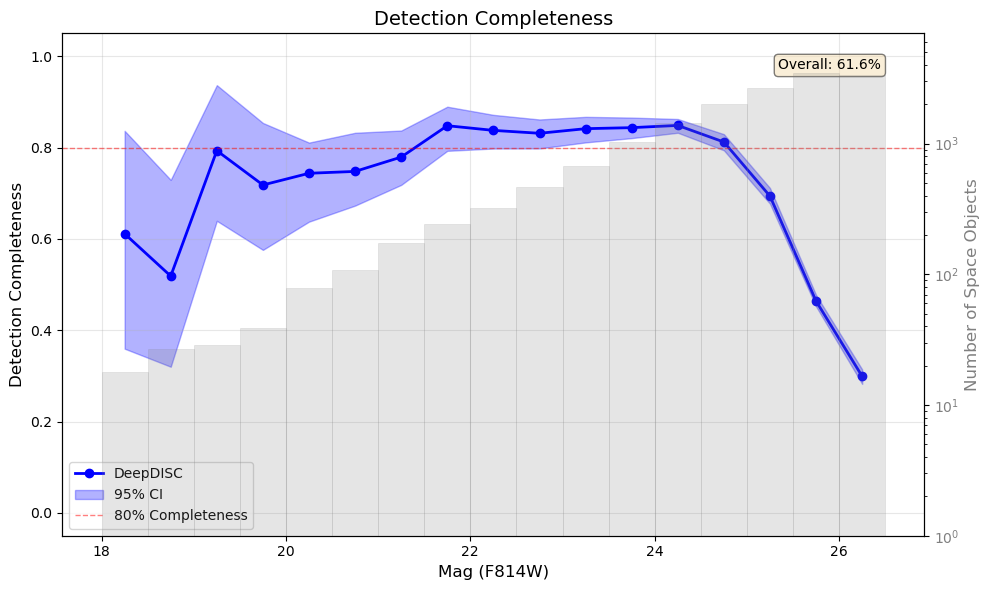

In [63]:
mag_bins = np.arange(18, 27, 0.5)
results = run_comp_analysis(
    ground_cat, 
    space_cat[space_cat['mag_F814W'] < 26.4],
    mag_col='mag_F814W',      # mag col in space cat
    mag_bins=mag_bins,  # magnitude bins
    n_bootstrap=100,
    show_errors=True,             # show error bars/bands
    error_style='bands',          # 'bands' or 'bars'
    show_distribution=True,       # show magnitude distribution
    confidence_level=0.95         # 95% confidence intervals
)

# Access results
print(f"\nFinal overall completeness: {results['overall_completeness']:.1%}")
if results['overall_ci'] is not None:
    print(f"95% CI: ({results['overall_ci'][0]:.1%}, {results['overall_ci'][1]:.1%})")

# Detection Completeness Comparison

In [74]:
dd_ground_cat = pd.read_json('pred_s0.45_n0.3.json', orient='records')
print(f"We loaded in {len(dd_ground_cat)} objects.")
# detect_isPrimary (primary objs don't have children - either isolated or deblended children)
# print(f"After detect_isPrimary cut: we have {len(ground_cat)} objects")

We loaded in 28024 objects.


In [75]:
lsst_ground_cat = pd.read_json('lsst_dets_hst.json', orient='records')
print(f"We loaded in {len(lsst_ground_cat)} objects.")
# detect_isPrimary (primary objs don't have children - either isolated or deblended children)
lsst_ground_cat = lsst_ground_cat[lsst_ground_cat['deblend_nChild'] == 0].copy()
print(f"After detect_isPrimary cut: we have {len(lsst_ground_cat)} objects")
# ground_cat = ground_cat[np.isfinite(ground_cat['mag_i'])].copy()
# there's some mags that are 83 so wet set 30 as the upper limit
# ground_cat = ground_cat[ground_cat['mag_i'] <= 40].copy()
print(f"After first magnitude cuts: we have {len(lsst_ground_cat)} objects")
lsst_ground_cat.reset_index(drop=True, inplace=True) # drop=True prevents pandas from creating a new 'index' column

We loaded in 33512 objects.
After detect_isPrimary cut: we have 30000 objects
After first magnitude cuts: we have 30000 objects


In [66]:
def calc_comp(ground_cat, space_cat, label, 
              ground_coord_ra='ra', ground_coord_dec='dec',
              max_sep=2.0*u.arcsec, mag_col='mag_F814W', 
              mag_bins=None, n_bootstrap=100, confidence_level=0.95):
    """
    Runs the full completeness analysis for one ground catalog and returns the results.
    """
    print(f"--- Processing Catalog: {label} ---")
    
    space_detected = find_comp_mask(ground_cat, space_cat, max_sep,
                                    ground_coord_ra=ground_coord_ra, # Pass the RA column name
                                    ground_coord_dec=ground_coord_dec)
    overall_completeness = np.sum(space_detected) / len(space_cat)
    print(f"Overall completeness: {overall_completeness:.1%}")

    # binned completeness
    mag_centers, comps, counts, detected_counts = comp_by_mag(
        space_cat, space_detected, mag_col, mag_bins
    )
    # bootstrap for errors if requested
    errors_lower, errors_upper = None, None
    if n_bootstrap > 0:
        overall_samples, binned_samples = bootstrap_comp(
            space_cat, space_detected, n_bootstrap, mag_col, mag_bins
        )
        alpha = 1 - confidence_level
        lower_percentile = (alpha / 2) * 100
        upper_percentile = (1 - alpha / 2) * 100
        errors_lower = np.nanpercentile(binned_samples, lower_percentile, axis=0)
        errors_upper = np.nanpercentile(binned_samples, upper_percentile, axis=0)

    return {
        'label': label,
        'mag_centers': mag_centers,
        'completeness': comps,
        'overall_completeness': overall_completeness,
        'errors_lower': errors_lower,
        'errors_upper': errors_upper,
    }

def plot_mult_comp(results_list, space_cat, mag_bins,
                    mag_col='mag_F814W', colors=None):
    """
    Plots completeness curves for multiple analysis results on the same axes.
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    if colors is None:
        colors = plt.cm.viridis(np.linspace(0, 1, len(results_list)))
    
    summary_text_parts = []
    # --- Loop through each result and plot its completeness curve ---
    for i, result in enumerate(results_list):
        label = result['label']
        mag_centers = result['mag_centers']
        comp = result['completeness']
        errors_lower = result['errors_lower']
        errors_upper = result['errors_upper']
        color = colors[i]
        
        # Main comp plot for this result
        valid = ~np.isnan(comp)
        ax1.plot(mag_centers[valid], comp[valid], 'o-', color=color,
                 linewidth=2, markersize=6, label=label)
        
        # Add shaded error bands if they exist
        if errors_lower is not None and errors_upper is not None:
            ax1.fill_between(mag_centers[valid], errors_lower[valid],
                             errors_upper[valid], alpha=0.2, color=color)
        summary_text_parts.append(f"{label}: {result['overall_completeness']:.1%}")

    # --- Plot shared elements (axes, labels, histogram) ---
    ax1.set_xlabel(f'Mag ({mag_col})', fontsize=12)
    ax1.set_ylabel('Detection Completeness', fontsize=12)
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, which='both', alpha=0.3)
    ax1.set_title('Detection Completeness Comparison for DP1 Data', fontsize=14)
    ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, linewidth=1, label='80% Completeness')
    
    # Plot the space cat mag distribution on a secondary axis
    ax2 = ax1.twinx()
    mags = space_cat[mag_col].values
    mags_clean = mags[np.isfinite(mags)]
    ax2.hist(mags_clean, bins=mag_bins, color='gray', alpha=0.2, edgecolor='gray')
    ax2.set_ylabel('Number of Space Objects', fontsize=12, color='gray')
    ax2.set_yscale('log')
    ax2.tick_params(axis='y', labelcolor='gray')

    summary_text = '\n'.join(summary_text_parts)
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    # Place text box in the top-right corner of the axes
    ax1.text(0.95, 0.95, summary_text, transform=ax1.transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right', bbox=props)
    
    ax1.legend(loc='lower left')
    plt.tight_layout()

--- Processing Catalog: DeepDISC ---
Found 3740 1-1 matched pairs out of 4650 space objects
Overall completeness: 80.4%
Bootstrap sample 0/500
Bootstrap sample 100/500
Bootstrap sample 200/500
Bootstrap sample 300/500
Bootstrap sample 400/500
--- Processing Catalog: LSST Pipeline ---
Found 3941 1-1 matched pairs out of 4650 space objects
Overall completeness: 84.8%
Bootstrap sample 0/500
Bootstrap sample 100/500
Bootstrap sample 200/500
Bootstrap sample 300/500
Bootstrap sample 400/500


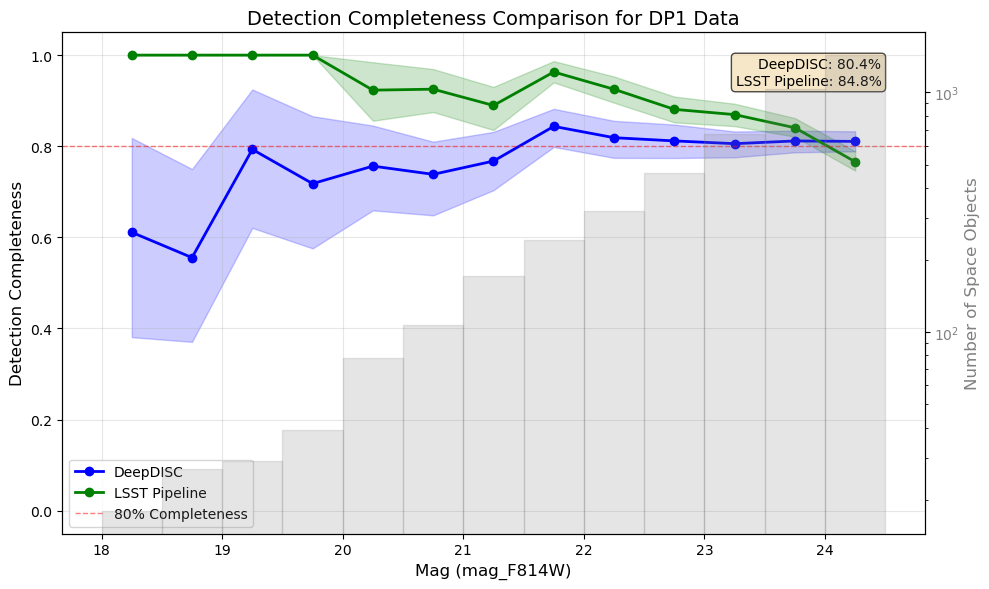

In [159]:
mag_bins = np.arange(18, 25, 0.5)
mag_col = 'mag_F814W'
n_bootstrap = 500

results1 = calc_comp(
    ground_cat=dd_ground_cat,
    space_cat=space_cat[space_cat['mag_F814W'] < 24.5],
    label='DeepDISC',
    mag_bins=mag_bins,
    mag_col=mag_col,
    n_bootstrap=n_bootstrap
)

results2 = calc_comp(
    ground_cat=lsst_ground_cat,
    space_cat=space_cat[space_cat['mag_F814W'] < 24.5],
    label='LSST Pipeline',
    ground_coord_ra='coord_ra',
    ground_coord_dec='coord_dec',
    mag_bins=mag_bins,
    mag_col=mag_col,
    n_bootstrap=n_bootstrap
)

plot_mult_comp(
    results_list=[results1, results2],
    space_cat=space_cat,
    mag_bins=mag_bins,
    mag_col=mag_col,
    colors=['blue', 'green']
)

# Detection Purity

In [70]:
def find_purity_mask(ground_cat, space_cat, max_sep=2.0*u.arcsec,
                     ground_coord_ra='ra', ground_coord_dec='dec'):
    """
    Which ground detections are real? (Purity)
    Returns a boolean mask for the GROUND catalog
    """
    # basically the same as find_comp_mask but final step is diff
    if len(ground_cat) == 0 or len(space_cat) == 0:
        return np.zeros(len(ground_cat), dtype=bool)

    gcoord = SkyCoord(ground_cat[ground_coord_ra].values*u.deg,
                      ground_cat[ground_coord_dec].values*u.deg)
    scoord = SkyCoord(space_cat['RA'].values*u.deg,
                      space_cat['DEC'].values*u.deg)

    idx_ground, d2d, _ = gcoord.match_to_catalog_sky(scoord)
    good_sep = d2d <= max_sep
    
    unique_space, space_counts = np.unique(idx_ground[good_sep], return_counts=True)
    good_space_idxs = unique_space[space_counts == 1]
    # Mark which GROUND dets are part of a valid 1-to-1 match
    ground_purity_mask = good_sep & np.isin(idx_ground, good_space_idxs)
    print(f"{np.sum(ground_purity_mask)} were actual matched detections out of {len(ground_cat)} total detections.")
    return ground_purity_mask

def purity_by_mag(ground_cat, ground_purity_mask, ground_mag_col='mag_i',
                  mag_bins=None, min_per_bin=10):
    """
    Calculate detection purity as a function of ground catalog mag
    """
    mags = ground_cat[ground_mag_col].values

    if mag_bins is None:
        mag_bins = np.arange(18, 28.5, 0.5)

    mag_centers = (mag_bins[:-1] + mag_bins[1:]) / 2
    purities = []
    total_counts = []
    tp_counts = []

    for i in range(len(mag_bins) - 1):
        in_bin = (mags >= mag_bins[i]) & (mags < mag_bins[i+1])
        n_total = np.sum(in_bin)
        n_tp = np.sum(in_bin & ground_purity_mask)

        if n_total >= min_per_bin:
            purity = n_tp / n_total
        else:
            purity = np.nan

        purities.append(purity)
        total_counts.append(n_total)
        tp_counts.append(n_tp)

    return mag_centers, np.array(purities), np.array(total_counts), np.array(tp_counts)

def bootstrap_purity(ground_cat, ground_purity_mask, n_bootstrap=100,
                     ground_mag_col='mag_i', mag_bins=None, seed=42):
    """
    Calculates bootstrap confidence intervals for purity by resampling the ground cat
    """
    np.random.seed(seed)
    n_ground = len(ground_cat)

    if mag_bins is None:
        mag_bins = np.arange(18, 28.5, 0.5)

    overall_samples = []
    binned_samples = []

    for i in range(n_bootstrap):
        # Resample the INDICES of the ground catalog
        idx = np.random.choice(n_ground, n_ground, replace=True)

        # Create bootstrap samples of the catalog and the purity mask
        ground_boot = ground_cat.iloc[idx].reset_index(drop=True)
        purity_mask_boot = ground_purity_mask[idx]

        # Calculate overall purity for this sample
        overall_purity = np.sum(purity_mask_boot) / len(ground_boot)
        overall_samples.append(overall_purity)

        # Calculate binned purity for this sample
        _, purity_boot, _, _ = purity_by_mag(
            ground_boot, purity_mask_boot, ground_mag_col, mag_bins
        )
        binned_samples.append(purity_boot)

    return np.array(overall_samples), np.array(binned_samples)

def plot_purity(mag_centers, purity, ground_cat, mag_bins, overall_purity,
                ground_mag_col='mag_i', errors_lower=None, errors_upper=None,
                show_errors=True, error_style='bands', show_distribution=True,
                title='Detection Purity'):
    """
    Plot detection purity with optional error bars/bands and ground mag distribution
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))

    valid = ~np.isnan(purity)
    ax1.plot(mag_centers[valid], purity[valid], 'o-', color='royalblue',
             linewidth=2, markersize=6, label='DeepDISC')

    # Add error bands
    if show_errors and errors_lower is not None and errors_upper is not None:
        ax1.fill_between(mag_centers[valid], errors_lower[valid],
                         errors_upper[valid], alpha=0.3, color='royalblue',
                         label='95% CI')

    ax1.set_xlabel(f'Mag ({ground_mag_col})', fontsize=12)
    ax1.set_ylabel('Detection Purity', fontsize=12)
    ax1.tick_params(axis='y')
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, alpha=0.3)
    ax1.set_title(title, fontsize=14)
    ax1.legend(loc='lower left')

    # Add text box with the true, overall purity
    textstr = f'Overall Purity: {overall_purity:.1%}'
    props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.5)
    ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right', bbox=props)

    # Add magnitude distribution of the GROUND catalog
    if show_distribution:
        ax2 = ax1.twinx()
        mags = ground_cat[ground_mag_col].values
        mags_clean = mags[np.isfinite(mags)]
        counts, _, _ = ax2.hist(mags_clean, bins=mag_bins, color='gray',
                                alpha=0.2, edgecolor='gray')
        ax2.set_ylabel('Number of Ground Detections', fontsize=12, color='gray')
        ax2.set_yscale('log')
        ax2.tick_params(axis='y', labelcolor='gray')
        ax2.set_ylim(1, np.max(counts) * 2)

    plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=150, bbox_inches='tight')

def run_purity_analysis(ground_cat, space_cat, max_sep=2.0*u.arcsec,
                        ground_coord_ra='ra', ground_coord_dec='dec',
                        ground_mag_col='mag_i', mag_bins=None,
                        n_bootstrap=100, confidence_level=0.95,
                       plot_result=True):
    """
    Runs the full purity analysis pipeline and plots the results.
    """
    print("--- Calculating Detection Purity ---")
    
    ground_purity_mask = find_purity_mask(
        ground_cat, space_cat, max_sep, ground_coord_ra, ground_coord_dec
    )
    overall_purity = np.sum(ground_purity_mask) / len(ground_cat) if len(ground_cat) > 0 else 0

    mag_centers, purities, total_counts, tp_counts = purity_by_mag(
        ground_cat, ground_purity_mask, ground_mag_col, mag_bins
    )
    print("\n------ Purity by Detected Magnitude ------")
    for i, (mc, p, n, nd) in enumerate(zip(mag_centers, purities, total_counts, tp_counts)):
        if not np.isnan(p):
            print(f"  {mag_bins[i]:.1f}-{mag_bins[i+1]:.1f}: "
                  f"{nd:4d}/{n:4d} = {p:.1%}")

    errors_lower, errors_upper = None, None
    if n_bootstrap > 0:
        print(f"\nRunning bootstrap with {n_bootstrap} samples for purity...")
        overall_samples, binned_samples = bootstrap_purity(
            ground_cat, ground_purity_mask, n_bootstrap, ground_mag_col, mag_bins
        )
        alpha = 1 - confidence_level
        lower_p = (alpha / 2) * 100
        upper_p = (1 - alpha / 2) * 100
        overall_ci = np.percentile(overall_samples, [lower_p, upper_p])
        print(f"Overall Purity: {overall_purity:.1%} "
              f"({overall_ci[0]:.1%}, {overall_ci[1]:.1%})")
        errors_lower = np.nanpercentile(binned_samples, lower_p, axis=0)
        errors_upper = np.nanpercentile(binned_samples, upper_p, axis=0)
    if plot_result:
        plot_purity(
            mag_centers, purities, ground_cat, mag_bins, overall_purity,
            ground_mag_col=ground_mag_col, errors_lower=errors_lower, errors_upper=errors_upper
        )
    
    results = {
        'overall_purity': overall_purity,
        'overall_ci': overall_ci,
        'mag_centers': mag_centers,
        'purity': purities,
        'errors_lower': errors_lower,
        'errors_upper': errors_upper,
        'ground_purity_mask': ground_purity_mask
    }
    
    return results

--- Calculating Detection Purity ---
8582 were actual matched detections out of 15709 total detections.

------ Purity by Detected Magnitude ------
  18.0-18.5:   12/  31 = 38.7%
  18.5-19.0:   16/  57 = 28.1%
  19.0-19.5:   21/  55 = 38.2%
  19.5-20.0:   33/  84 = 39.3%
  20.0-20.5:   51/ 134 = 38.1%
  20.5-21.0:   83/ 187 = 44.4%
  21.0-21.5:  115/ 262 = 43.9%
  21.5-22.0:  206/ 377 = 54.6%
  22.0-22.5:  261/ 522 = 50.0%
  22.5-23.0:  356/ 735 = 48.4%
  23.0-23.5:  537/ 997 = 53.9%
  23.5-24.0:  741/1336 = 55.5%
  24.0-24.5:  990/1778 = 55.7%
  24.5-25.0: 1299/2202 = 59.0%
  25.0-25.5: 1343/2418 = 55.5%
  25.5-26.0: 1405/2485 = 56.5%
  26.0-26.5: 1105/1971 = 56.1%

Running bootstrap with 100 samples for purity...
Overall Purity: 54.6% (53.9%, 55.3%)

Final overall completeness: 54.6%
95% CI: (53.9%, 55.3%)


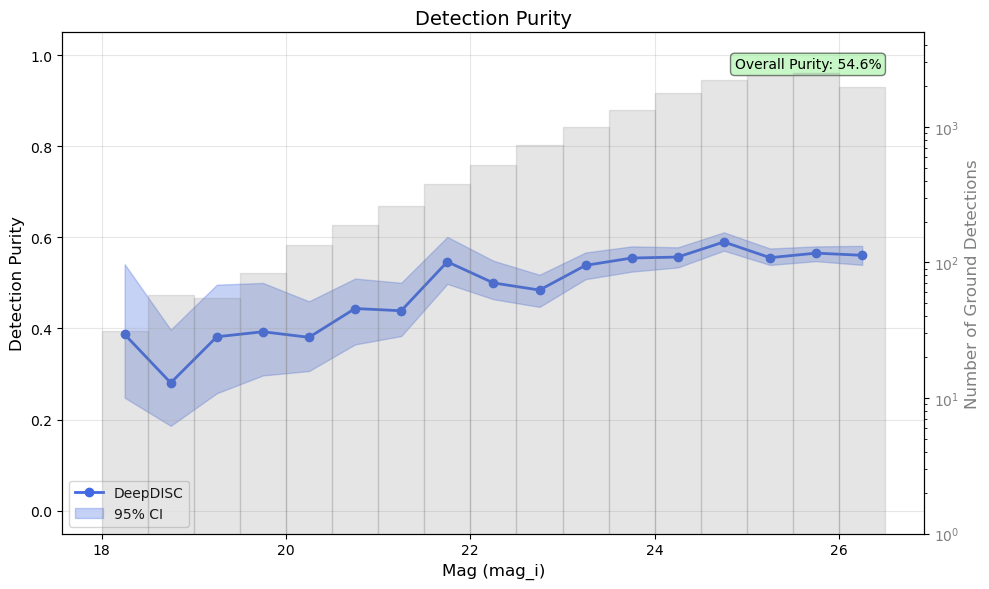

In [71]:
mag_bins = np.arange(18, 27, 0.5)
results = run_purity_analysis(
    dd_ground_cat[dd_ground_cat['mag_i'] <= 26.4], 
    space_cat,
    mag_bins=mag_bins,  # magnitude bins
    n_bootstrap=100,
    confidence_level=0.95         # 95% confidence intervals
)

# Access results
print(f"\nFinal overall completeness: {results['overall_purity']:.1%}")
if results['overall_ci'] is not None:
    print(f"95% CI: ({results['overall_ci'][0]:.1%}, {results['overall_ci'][1]:.1%})")

# Detection Purity Comparison

In [72]:
def plot_mult_purity(results_list, ground_cat_list, mag_bins, ground_mag_col='mag_i'):
    """
    Plots purity results for multiple cats on vertically stacked subplots.

    Args:
        results_list (list): A list of the result dictionaries from run_purity_analysis.
        ground_cat_list (list): A list of the corresponding ground catalogs.
        mag_bins (array): The magnitude bins used for the x-axis.
        ground_mag_col (str): The name of the magnitude column in the ground catalogs.
    """
    fig, axes = plt.subplots(
        nrows=2, ncols=1,
        sharex=True,
        figsize=(10, 9) # Taller figure to accommodate two plots
    )

    colors = ['seagreen', 'royalblue'] # LSST, DeepDISC
    
    for i, (ax, result, ground_cat) in enumerate(zip(axes, results_list, ground_cat_list)):
        # Extract data from the result dictionary
        purity = result['purity']
        mag_centers = result['mag_centers']
        errors_lower = result['errors_lower']
        errors_upper = result['errors_upper']
        overall_purity = result['overall_purity']
        
        # --- This is the same plotting logic as plot_purity, but on `ax` ---
        valid = ~np.isnan(purity)
        ax.plot(mag_centers[valid], purity[valid], 'o-', color=colors[i],
                linewidth=2, markersize=6)

        if errors_lower is not None and errors_upper is not None:
            ax.fill_between(mag_centers[valid], errors_lower[valid],
                            errors_upper[valid], alpha=0.25, color=colors[i])

        ax.set_ylabel('Detection Purity', fontsize=12)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.set_title(result['label'], fontsize=14)
        
        # Add text box with overall purity for this subplot
        textstr = f'Overall Purity: {overall_purity:.1%}'
        props = dict(boxstyle='round', facecolor=colors[i], alpha=0.2)
        ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right', bbox=props)

        # Add the magnitude distribution histogram on a secondary y-axis
        ax_hist = ax.twinx()
        mags = ground_cat[ground_mag_col].values
        mags_clean = mags[np.isfinite(mags)]
        ax_hist.hist(mags_clean, bins=mag_bins, color='gray', alpha=0.2)
        ax_hist.set_ylabel('N Detections', fontsize=12, color='gray')
        ax_hist.set_yscale('log')
        ax_hist.tick_params(axis='y', labelcolor='gray')
        
    # --- Final figure-level adjustments ---
    # Set the shared x-axis label only on the bottom plot
    axes[1].set_xlabel(f' Mag i ({ground_mag_col})', fontsize=12)
    
    fig.suptitle('Detection Purity Comparison', fontsize=16, y=0.96)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

--- Calculating Detection Purity ---
13625 were actual matched detections out of 22276 total detections.

------ Purity by Detected Magnitude ------
  18.0-18.5:   12/  26 = 46.2%
  18.5-19.0:   35/  61 = 57.4%
  19.0-19.5:   26/  44 = 59.1%
  19.5-20.0:   42/  79 = 53.2%
  20.0-20.5:   77/ 128 = 60.2%
  20.5-21.0:  106/ 185 = 57.3%
  21.0-21.5:  155/ 270 = 57.4%
  21.5-22.0:  272/ 448 = 60.7%
  22.0-22.5:  337/ 576 = 58.5%
  22.5-23.0:  488/ 826 = 59.1%
  23.0-23.5:  745/1190 = 62.6%
  23.5-24.0: 1115/1780 = 62.6%
  24.0-24.5: 1580/2476 = 63.8%
  24.5-25.0: 2067/3309 = 62.5%
  25.0-25.5: 2594/4132 = 62.8%
  25.5-26.0: 2597/4291 = 60.5%
  26.0-26.5: 1361/2404 = 56.6%

Running bootstrap with 500 samples for purity...
Overall Purity: 61.2% (60.6%, 61.8%)
--- Calculating Detection Purity ---
8582 were actual matched detections out of 15709 total detections.

------ Purity by Detected Magnitude ------
  18.0-18.5:   12/  31 = 38.7%
  18.5-19.0:   16/  57 = 28.1%
  19.0-19.5:   21/  55 = 38

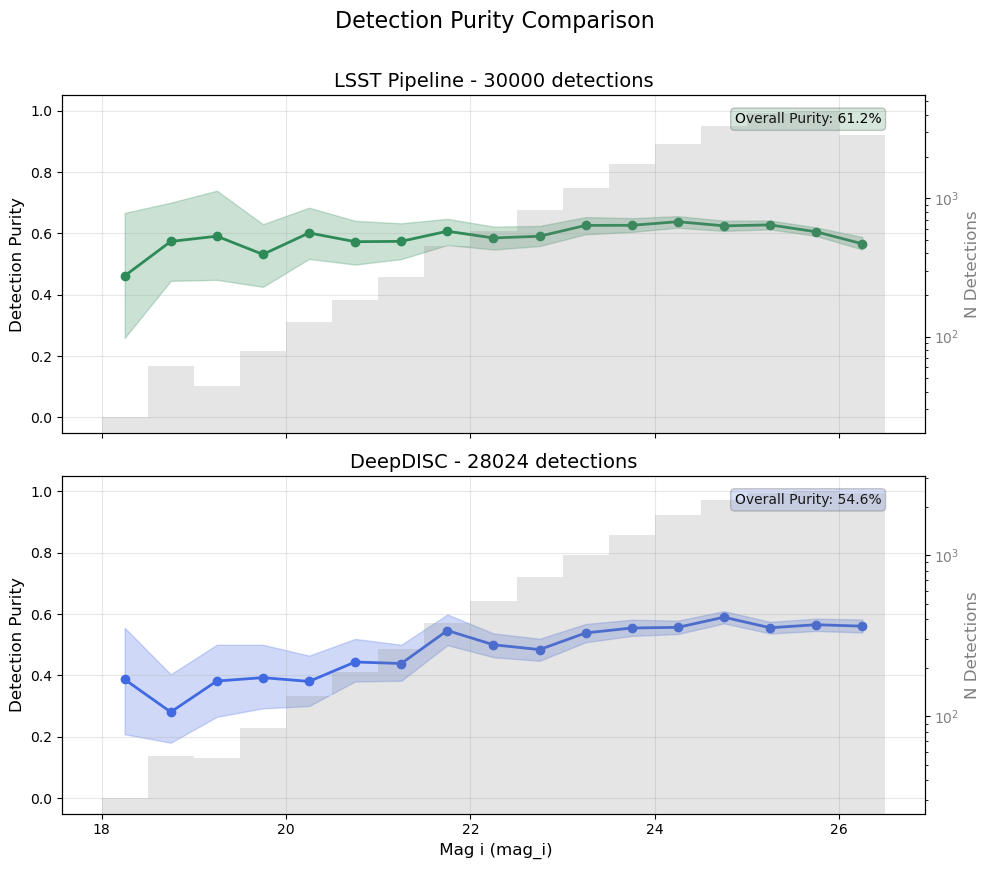

In [77]:
mag_bins = np.arange(18, 27, 0.5)
n_bootstrap = 500

results_lsst = run_purity_analysis(
    lsst_ground_cat[lsst_ground_cat['mag_i'] <= 26.4], 
    space_cat,
    ground_coord_ra='coord_ra',
    ground_coord_dec='coord_dec',
    mag_bins=mag_bins,  # magnitude bins
    n_bootstrap=n_bootstrap,
    confidence_level=0.95,
    plot_result=False
)
results_lsst['label'] = f'LSST Pipeline - {len(lsst_ground_cat)} detections' 

results_dd = run_purity_analysis(
    dd_ground_cat[dd_ground_cat['mag_i'] <= 26.4], 
    space_cat,
    mag_bins=mag_bins,  # magnitude bins
    n_bootstrap=n_bootstrap,
    confidence_level=0.95,
    plot_result=False
)
results_dd['label'] = f'DeepDISC - {len(dd_ground_cat)} detections' 

plot_mult_purity(
    results_list=[results_lsst, results_dd], # pass in order (top, bottom)
    ground_cat_list=[lsst_ground_cat, dd_ground_cat],
    mag_bins=mag_bins,
    ground_mag_col='mag_i'
)